In [10]:
import torch
from torch import nn
from torch.utils.data import random_split, DataLoader, Subset
from torchvision import datasets
from torchvision.transforms import ToTensor
import numpy as np
import os
import pandas as pd
from torch.utils.data import Dataset
# import sklearn
from sklearn.model_selection import train_test_split
from torchvision.transforms import ToTensor, Lambda
import matplotlib.colors as mcolors

from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import StratifiedKFold


import matplotlib.pyplot as plt
import wandb


import os
import datetime


In [2]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)

In [3]:
print(device)

mps


In [4]:
#This is in place to fix all variables so I can gauge how effective changes are 
torch.manual_seed(42)
np.random.seed(42)

# Make training deterministic
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


#### **Put data into a database**

In [19]:

class CustomDataset(Dataset):
    def __init__(self, labels, data, dir, transform=None, target_transform=None):
        self.labels = labels
        self.data = data
        self.dir = dir
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        
        data = self.data[idx]
        label = self.labels[idx]

        data = torch.from_numpy(data).type(torch.float)
        label = torch.tensor(label)

        if self.transform:
            data = self.transform(data)
        if self.target_transform:
            label = self.target_transform(label)
                            
        return data, label

In [15]:
#--- Create the dataset ---# 

# 0:Met[Zsun],1:Age[Gyr],2:Rp[Rsun],3:Vinf[km/s],4:Mass1_i[MSUN],5:Mass2_i[Msun],6:R1[Rsun],7:R2[Rsun],8:Label,9:Mass1_f[MSUN],10:Mass2_f[MSUN],11:Sigma
# data_dir = '/projects/b1091/SPH_ML_grid/machine_learning/data_n10k_splot19f.csv'
# data_dir = '/projects/b1091/SPH_ML_grid/machine_learning/data_n10k_splot22f.csv'
data_dir = '../../data_n10k_splot22f.csv'

data_loaded  = np.loadtxt(data_dir, delimiter=',', dtype=float, skiprows = 1)

# Selecting only the columns I want to have the format: 
# 0:Met[Zsun], 1:Age[Gyr], 2:Rp[Rsun], 3:Vinf[km/s], 4:Mass1[MSUN], 5:Mass2[MSUN], 6:Label
data = data_loaded[:, [0, 1, 2, 3, 4, 5, 8]]

y_data = data[:,-1].astype(np.int64)
x_data = data[:, 1:-1]

#Feature transform: log the x-data
x_data[:, 0] = np.log10(x_data[:, 0]) # log ages
x_data[:, 2] = np.log10(x_data[:, 2]) # log vinfs
y_data[y_data < 0] = 3 #replace locally the meaning of label -1
print(np.shape(x_data), np.shape(y_data))

#Save the original input for later 
x_data_og = x_data
#Split into Training + Temporary (Validation + Test)
X_train, X_temp, y_train, y_temp = train_test_split(x_data, y_data, test_size=0.30, stratify = y_data, random_state=42)

# Split the temporary into validation and testing sets 
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify = y_temp, random_state=42)

print(np.shape(X_train), np.shape(X_val), np.shape(X_test))

# Standard Normalize the data 
train_mean = X_train.mean(axis=0)
train_std = X_train.std(axis=0)

X_train = (X_train - train_mean) / train_std
X_test = (X_test - train_mean) / train_std  # apply train stats
X_val = (X_val - train_mean) / train_std  # apply train stats

# Define the transform - One-Hot encoded
transform = None
num_classes = 4
target_transform = Lambda(lambda y: torch.zeros(num_classes, dtype=torch.float).scatter_(0, y, value=1))

# Create separate datasets for train and test
train_dataset = CustomDataset(dir=data_dir, labels = y_train, data = X_train, transform=transform, target_transform = target_transform)
val_dataset = CustomDataset(dir=data_dir, labels = y_val, data = X_val, transform=transform, target_transform = target_transform)
test_dataset = CustomDataset(dir=data_dir, labels = y_test, data = X_test, transform=transform, target_transform = target_transform)

#Take this out for final iteration, it is here to make sure data is shuffled the same each time
g = torch.Generator()
g.manual_seed(42)

train_dataloader = DataLoader(train_dataset, batch_size=512, shuffle=True, generator=g)
val_dataloader = DataLoader(val_dataset, batch_size=128, shuffle=False, generator=g)
test_dataloader = DataLoader(test_dataset, batch_size=128, shuffle=False, generator=g)


for batch_data, (batch_labels) in train_dataloader:

    print("Batch data shape:", batch_data.shape)   # Correct way to check shape
    print("Batch labels shape:", batch_labels.shape)
    print("Labels dtype:", batch_labels.dtype)


(21473, 5) (21473,)
(15031, 5) (3221, 5) (3221, 5)
Batch data shape: torch.Size([512, 5])
Batch labels shape: torch.Size([512, 4])
Labels dtype: torch.float32
Batch data shape: torch.Size([512, 5])
Batch labels shape: torch.Size([512, 4])
Labels dtype: torch.float32
Batch data shape: torch.Size([512, 5])
Batch labels shape: torch.Size([512, 4])
Labels dtype: torch.float32
Batch data shape: torch.Size([512, 5])
Batch labels shape: torch.Size([512, 4])
Labels dtype: torch.float32
Batch data shape: torch.Size([512, 5])
Batch labels shape: torch.Size([512, 4])
Labels dtype: torch.float32
Batch data shape: torch.Size([512, 5])
Batch labels shape: torch.Size([512, 4])
Labels dtype: torch.float32
Batch data shape: torch.Size([512, 5])
Batch labels shape: torch.Size([512, 4])
Labels dtype: torch.float32
Batch data shape: torch.Size([512, 5])
Batch labels shape: torch.Size([512, 4])
Labels dtype: torch.float32
Batch data shape: torch.Size([512, 5])
Batch labels shape: torch.Size([512, 4])
Label

### **Build Neural Network**

In [24]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        # Shared layers
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(5, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 4),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

In [26]:


def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)

    model = model.to(device)
    model.train()

    train_loss, correct = 0, 0
    y_true = [] # Store labels for balanced accuracy
    y_pred = []  # Store labels for balanced accuracy

    for X, y in dataloader:
        X = X.to(device)
        y = y.to(device)

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)
        train_loss += loss.item()

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Log metrics to wandb.
        correct += (pred.argmax(dim = 1) == y.argmax(dim = 1)).type(torch.float).sum().item()

        # correct += (pred.argmax(dim=1) == y).type(torch.float).sum().item()
        # Store predictions and true labels
        y_true.extend(y.argmax(dim = 1).detach().cpu().numpy())  # Convert tensors to NumPy
        y_pred.extend(pred.argmax(dim = 1).detach().cpu().numpy())

    train_loss /= num_batches
    correct /= size
    balanced_acc = balanced_accuracy_score(y_true, y_pred)
    # print(f"Train Error: \n Accuracy: {(100*correct):>0.1f}%, Balanced Accuracy: {(100*balanced_acc):>0.1f}%, Avg loss: {train_loss:>8f} \n")

    # Log metrics to wandb.
    run.log({"train_acc": 100*correct, "train_balanced_acc": 100*balanced_acc, "train_loss": train_loss})

def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model = model.to(device)
    model.eval()
    val_loss, correct = 0, 0
    y_true = [] # Store labels for balanced accuracy
    y_pred = []  # Store labels for balanced accuracy
    with torch.no_grad():
        for X, y in dataloader:
            X = X.to(device)
            y = y.to(device)

            pred = model(X)
            val_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(dim = 1) == y.argmax(dim = 1)).type(torch.float).sum().item()

            # Store predictions and true labels
            y_true.extend(y.argmax(dim = 1).detach().cpu().numpy())  # Convert tensors to NumPy
            y_pred.extend(pred.argmax(dim = 1).detach().cpu().numpy())

    val_loss /= num_batches
    correct /= size

    return val_loss



In [11]:
# Get today's date as string
date_str = datetime.datetime.now().strftime("%m%d")

# Safety stop in Jupyter
confirm = input("Type YES to continue: ")

if confirm != "YES":
    raise RuntimeError("Stopped — you didn’t confirm run.")
    

# Start a new wandb run to track this script.
run = wandb.init(
    # Set the wandb entity where your project will be logged (generally your team name).
    entity="elena-gonzalez-northwestern-university",
    # Set the wandb project where this run will be logged.
    project="ML_SPH_NN",
    name="W521_256_128_l3_500_classification_4",
    # Track hyperparameters and run metadata.
    config={
        "learning_rate": 'cosine_annealing',
        "architecture": "Classification_NN",
        "dataset": "data_n10k_splot22f.csv",
        "epochs": 1000,
        "width": 521_256_128, 
        "layers": 3,
        "batch_size": 512,
        "labels":4
    },
)

run_id = wandb.run.id  
model_name = f"model_{date_str}_{run_id}"

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: elena-gonzalez (elena-gonzalez-northwestern-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [27]:
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.utils.class_weight import compute_class_weight

# Get class weights for loss function 
# class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
# class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

# Set Hyper-parameters 
epochs = 1000

# Initialize list for storing validation loss for plotting
val_loss_history = []  # Store per-fold validation losses
lrs = []  # Store per-fold validation losses

best_val_score = np.inf
best_model_state = None

# Load the NN 
model = NeuralNetwork()
model = model.float()

# Set loss functions, optimizer, and learning rate scheduler
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
scheduler = CosineAnnealingLR(optimizer, T_max=epochs) 

# Begin the training 
for t in range(epochs):
    print(t)
    train(train_dataloader, model, loss_fn, optimizer)
    val_loss= test(val_dataloader, model, loss_fn)

    # Compute different accuracies for validation set
    size = len(val_dataloader.dataset)
    num_batches = len(val_dataloader)

    # balanced_acc = balanced_accuracy_score(y_true, y_pred)

    # Log metrics to wandb.
    # run.log({"val_acc": 100*correct, "val_balanced_acc": 100 * balanced_acc, "val_loss": val_loss, "class_val_loss": class_val_loss})

    if val_loss < best_val_score:
        best_val_score = val_loss
        best_model_state = model.state_dict()

    scheduler.step()  # update the learning rate
    lrs.append(optimizer.param_groups[0]['lr'])


print("Done!")

# Now save the best model as well as the data's mean and standard deviation
checkpoint = {
    "model_state_dict": best_model_state,
    "train_mean": train_mean,
    "train_std": train_std,
}
torch.save(checkpoint, model_name)

run.finish()


0
1
2
3
4
5
6
7
8
9
10
11
12


KeyboardInterrupt: 

In [23]:
model = NeuralNetwork()
model_name = ' model_08_27_nclass_4_funnel'
checkpoint = torch.load(model_name, map_location=torch.device('cuda'))
model.load_state_dict(checkpoint["model_state_dict"])
# Test the dataset 
# model.load_state_dict(best_model_state)

test_loss, class_test_loss, correct, y_true, y_pred = test(test_dataloader, model, loss_fn)

# Compute different accuracies for validation set
size = len(test_dataloader.dataset)
num_batches = len(test_dataloader)

# balanced_acc = balanced_accuracy_score(y_true, y_pred)

# print(f"\n Test Results:")
# print(f"Overall Test Loss: {test_loss:.4f}")
# print(f"Classification Loss: {class_test_loss:.4f}")
# print(f"Classification Accuracy: {100*correct:.2f}%")
# print(f"Balanced Classification Accuracy: {100*balanced_acc:.2f}%")

Test Error: 
 Accuracy: 96.2%, Balanced Accuracy: 91.4%, Avg loss: 0.090538 



/tmp/ipykernel_3730280/2353008264.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_name, map_location=torch.device('cuda'))


TypeError: cannot unpack non-iterable float object

In [9]:
import requests
from pathlib import Path 

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

helper_functions.py already exists, skipping download


In [10]:
model = NeuralNetwork()
model_name = ' model_06_09_nclass_4_funnel'
print("Loading model ", model_name)
model.load_state_dict(torch.load(model_name, map_location=torch.device('cuda')))
model.eval()  # set it to evaluation model

Loading model   model_06_09_nclass_4_funnel


/tmp/ipykernel_3848224/3599202113.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_name, map_location=torch.device('cuda')))


NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=5, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=4, bias=True)
  )
)

In [11]:
def plot_4d_decision_boundary(model, X_train, y_train, X_test, y_test, train_mean, train_std, num_classes, feature_idx=(0, 1), fixed_values={}, labels = []):
    """
    Plots the decision boundary for a PyTorch model using a 2D slice of a higher-dimensional space.
    
    Parameters:
    - model: Trained PyTorch model.
    -X, y:  data and labels.
    - feature_idx: Tuple (i, j) specifying which two features to plot.
    - fixed_values: Dictionary {feature_index: value} for fixing other dimensions.
    labels = list of strings 
    """

    # Step 1: Filter train and test data based on fixed_values
    for k, v in fixed_values.items():
        fixed_values[k] = (v - train_mean[k]) / train_std[k]
    
    train_mask = np.logical_and.reduce([np.isclose(X_train[:, k], v, rtol=0.01) for k, v in fixed_values.items()])
    test_mask = np.logical_and.reduce([np.isclose(X_test[:, k], v, rtol=0.01) for k, v in fixed_values.items()])

    if (train_mask.sum() == 0 and test_mask.sum() == 0):
        return "No data points!"

    X_train_filtered, y_train_filtered = X_train[train_mask], y_train[train_mask]
    X_test_filtered, y_test_filtered = X_test[test_mask], y_test[test_mask]
    
    # Step 2: Create a meshgrid for the chosen two features

    X_train_filtered_unnorm =  np.array(X_train_filtered)  * train_std + train_mean
    X_test_filtered_unnorm  =  np.array(X_test_filtered)   * train_std + train_mean
    
    x_min, x_max = X_train_filtered_unnorm[:, feature_idx[0]].min() - 0.1, X_train_filtered_unnorm[:, feature_idx[0]].max() + 0.1
    y_min, y_max = X_train_filtered_unnorm[:, feature_idx[1]].min() - 0.1, X_train_filtered_unnorm[:, feature_idx[1]].max() + 0.1

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500), np.linspace(y_min, y_max, 500))

    # Step 4: Standard normalize the data like you did before 
    xx_norm = (xx - train_mean[feature_idx[0]]) / train_std[feature_idx[0]]
    yy_norm = (yy - train_mean[feature_idx[1]]) / train_std[feature_idx[1]]

    # Step 3: Construct full-dimensional input space for predictions
    X_vis = torch.zeros((xx_norm.ravel().shape[0], X_train.shape[1]), dtype=torch.float32)
    X_vis[:, feature_idx[0]] = torch.tensor(xx_norm.ravel(), dtype=torch.float32)
    X_vis[:, feature_idx[1]] = torch.tensor(yy_norm.ravel(), dtype=torch.float32)

    # Assign fixed values to other dimensions
    for k, v in fixed_values.items():
        X_vis[:, k] = v

    # Step 4: Predict labels for meshgrid
    model.eval()
    with torch.no_grad():
        Z = model(X_vis).argmax(dim=1).numpy()
    Z = Z.reshape(xx.shape)

    # Normalize color mapping to match the scatter points and contour
    cmap = plt.cm.coolwarm  # Set the same colormap
    norm = mcolors.Normalize(vmin=0, vmax=2)  # Normalize colors

    if num_classes > 3: 

        cmap_base = plt.cm.coolwarm
        norm_base = mcolors.Normalize(vmin=0, vmax=2)
        # Build a list of colors by evaluating cmap for labels 0, 1, 2
        colors = [cmap_base(norm_base(i)) for i in range(3)]

        # Append a custom color for label 3 (e.g., green)
        colors.append((0.13, 0.55, 0.13, 1.0))  # green

        # Create a discrete colormap
        cmap = mcolors.ListedColormap(colors)

        # Define norm for discrete class labels 0–3
        norm = mcolors.BoundaryNorm(boundaries=[-0.5, 0.5, 1.5, 2.5, 3.5], ncolors=4)


    # Step 5: Plot decision boundary
    fig, ax = plt.subplots()
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap, norm=norm)

    # print(X_train_filtered_unnorm[:, feature_idx[1]])
    plt.scatter(X_train_filtered_unnorm[:, feature_idx[0]], X_train_filtered_unnorm[:, feature_idx[1]], c=y_train_filtered, cmap=cmap, norm = norm, edgecolor="k", marker='o', label = 'Train')
    plt.scatter(X_test_filtered_unnorm[:, feature_idx[0]], X_test_filtered_unnorm[:, feature_idx[1]], c=y_test_filtered, cmap=cmap, norm = norm, marker='^', label = 'Test' )
    plt.xlabel(fr" {labels[0]}", fontsize = 15)
    plt.ylabel(fr" {labels[1]}", fontsize = 15)
    plt.tick_params(axis='both', which='major', labelsize=13)  # or any size you prefer

    # plt.legend()
    # plt.title(f"NN: Decision Boundary Mass1 = {labels[2]} Msun , Mass2 = {labels[3]}Msun, Time = {round(10**(float(labels[4])),3)}Gyr")
    # plt.title(f"Mass1 = {labels[2]} Msun , Mass2 = {labels[3]}Msun, Time = {round(10**(float(labels[4])),3)}Gyr")
    plt.title(
    fr"$\mathrm{{M_1}} = {labels[2]}\ M_\odot,\ \mathrm{{M_2}} = {labels[3]}\ M_\odot,\ \mathrm{{Time}} = {round(10**(float(labels[4])),3)}\ \mathrm{{Gyr}}$", fontsize = 17)


    plt.tight_layout()
    return fig
    
    

Time:  -2.2365720064370627 Mass1: 32 Mass2: 32



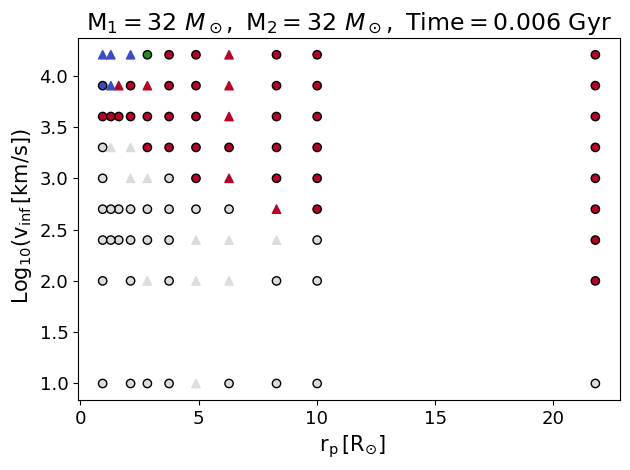

Time:  -2.2365720064370627 Mass1: 32 Mass2: 4



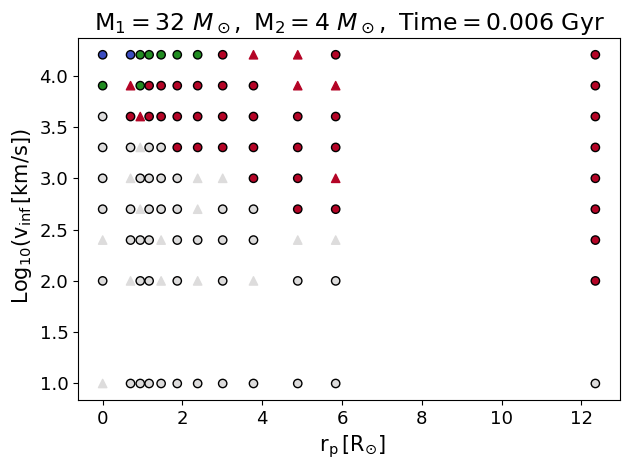

Time:  -2.2365720064370627 Mass1: 4 Mass2: 32

Time:  -2.2365720064370627 Mass1: 4 Mass2: 4



In [33]:
# 0:Age[Gyr],1:Rp,2:Vinf[km/s]3:Mass1[MSUN],4:Mass2[Msun],
from matplotlib.backends.backend_pdf import PdfPages
num_classes = 4
unique_times = [np.log10(0.0058)]
unique_mass = [32,4]
for time in unique_times:
    for mass1 in unique_mass:
        for mass2 in unique_mass:
            print("Time: ", str(time) + " Mass1: " + str(mass1) + " Mass2: " + str(mass2) + '\n' )
            labels = [r'$\rm r_p \, [R_{\odot}]$', r'$\rm Log_{10}(v_{inf} \, [km/s])$', str(mass1), str(round(mass2,2)), str(time)]

            fig = plot_4d_decision_boundary(model, train_dataset.data, train_dataset.labels, test_dataset.data, test_dataset.labels, train_mean, train_std, num_classes, feature_idx=(1, 2), fixed_values={0: time, 3: mass1, 4: mass2}, labels = labels)
            if fig != "No data points!":
                # Save the current figure to the PDF
                pdf.savefig(fig , bbox_inches='tight')  # Saves the current figure
                plt.show()
                plt.close(fig )    # Close it to avoid overlap

In [17]:
print( np.unique(x_data_og[:,0]))

[-3.         -2.52287875 -2.39794001 -2.25181197 -2.23657201 -2.
 -1.95860731 -1.74472749 -1.537602   -1.49485002 -1.         -0.89619628
 -0.50031292 -0.25026368 -0.22184875  0.          0.49996187  0.70001106
  1.          1.04848065  1.13672057]


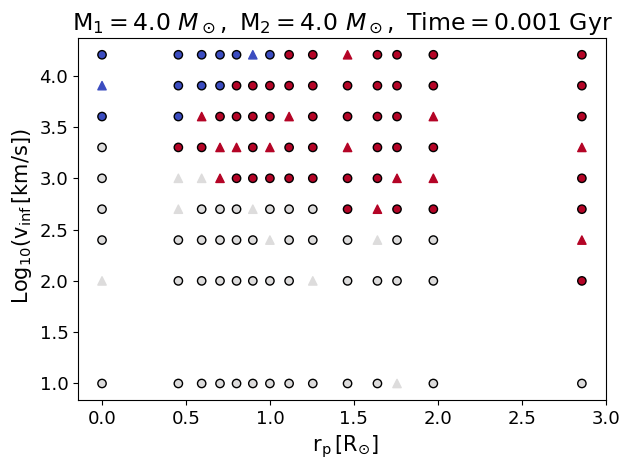

KeyboardInterrupt: 

In [14]:
# 0:Age[Gyr],1:Rp,2:Vinf[km/s]3:Mass1[MSUN],4:Mass2[Msun],
from matplotlib.backends.backend_pdf import PdfPages
num_classes = 4
unique_times = np.unique(x_data_og[:,0])
unique_mass = np.unique(x_data_og[:,4])
with PdfPages('decision_boundary_plots_22f.pdf') as pdf:
    for time in unique_times:
        for mass1 in unique_mass:
            for mass2 in unique_mass:
                # print("Time: ", str(time) + " Mass1: " + str(mass1) + " Mass2: " + str(mass2) + '\n' )
                labels = [r'$\rm r_p \, [R_{\odot}]$', r'$\rm Log_{10}(v_{inf} \, [km/s])$', str(mass1), str(round(mass2,2)), str(time)]

                fig = plot_4d_decision_boundary(model, train_dataset.data, train_dataset.labels, test_dataset.data, test_dataset.labels, train_mean, train_std, num_classes, feature_idx=(1, 2), fixed_values={0: time, 3: mass1, 4: mass2}, labels = labels)
                if fig != "No data points!":
                    # Save the current figure to the PDF
                    pdf.savefig(fig , bbox_inches='tight')  # Saves the current figure
                    plt.show()
                    plt.close(fig )    # Close it to avoid overlap